In [36]:
import numpy as np
import pandas as pd

# Simulated dataset
np.random.seed(42)
n = 1000

# Treatment assignment (50/50 split)
treatment = np.random.binomial(1, 0.5, n)

# Baseline conversion rate
baseline_rate = 0.1

# Incremental lift for treatment group
lift = 0.05

# Outcomes
outcome = np.where(treatment == 1,
                   np.random.binomial(1, baseline_rate + lift, n),
                   np.random.binomial(1, baseline_rate, n))

df = pd.DataFrame({"treatment": treatment, "outcome": outcome})


In [37]:
df.head()

,treatment,outcome
0,0,0
1,1,0
2,1,1
3,1,0
4,0,0


In [3]:
#0 = control
#1 = treatment
df["treatment"].value_counts()

treatment
0    503
1    497
Name: count, dtype: int64

In [6]:
# 0 = not converted
# 1 = converted
df["outcome"].value_counts()

outcome
0    881
1    119
Name: count, dtype: int64

In [16]:
# Conversion rates
conv_treatment = df[df["treatment"] == 1]["outcome"].mean()
conv_control   = df[df["treatment"] == 0]["outcome"].mean()

# Incremental value
incremental_value = conv_treatment - conv_control

print(f"Treatment conversion rate: {conv_treatment:.3f}")
print(f"Control conversion rate:   {conv_control:.3f}")
print(f"Incremental value:         {incremental_value:.3f}")


Treatment conversion rate: 0.145
Control conversion rate:   0.093
Incremental value:         0.051


In [54]:
df[df["treatment"] == 1]["outcome"].value_counts()

outcome
0    425
1     72
Name: count, dtype: int64

In [20]:
df[df["treatment"] == 0]["outcome"].value_counts()

outcome
0    456
1     47
Name: count, dtype: int64

In [57]:
# Number of customers in treatment group
n_treatment = df["treatment"].sum()

# Incremental conversions
incremental_conversions = incremental_value * n_treatment
print(f"Incremental conversions: {incremental_conversions:.0f}")


Incremental conversions: 26


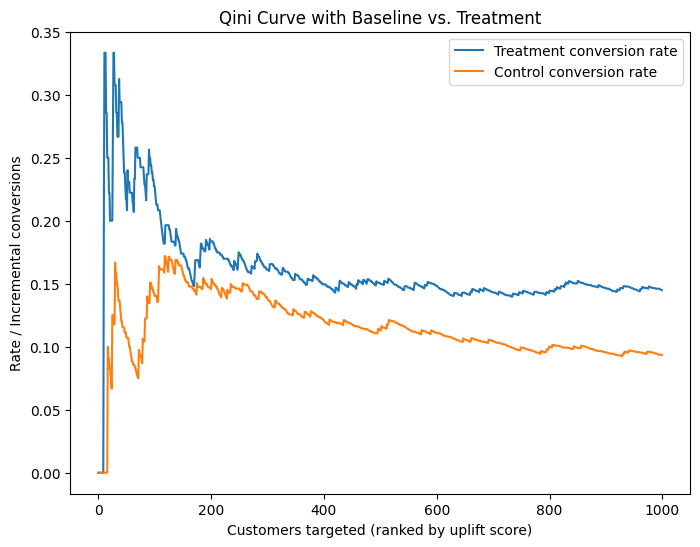

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Add random uplift scores (in practice, from your model)
df["uplift_score"] = np.random.rand(n)

# Sort by predicted uplift
df_sorted = df.sort_values("uplift_score", ascending=False).reset_index(drop=True)

# Compute cumulative incremental gain
cum_treat = df_sorted["treatment"].cumsum()
cum_control = (~df_sorted["treatment"].astype(bool)).cumsum()

cum_outcome_treat = (df_sorted["treatment"] * df_sorted["outcome"]).cumsum()  #treatment conversion cumsum
cum_outcome_control = ((1 - df_sorted["treatment"]) * df_sorted["outcome"]).cumsum()  #control conversion cumsum

# Response rates
rate_treat = cum_outcome_treat / cum_treat.replace(0, np.nan)
rate_control = cum_outcome_control / cum_control.replace(0, np.nan)

# Incremental conversions at each step
incremental_gain = (rate_treat - rate_control) * cum_treat

# Plot Qini curve
plt.figure(figsize=(8,6))
plt.plot(rate_treat, label="Treatment conversion rate")
plt.plot(rate_control, label="Control conversion rate")
#plt.plot(incremental_gain, label="Incremental gain (Qini curve)", linewidth=2, color="black")
plt.title("Qini Curve with Baseline vs. Treatment")
plt.xlabel("Customers targeted (ranked by uplift score)")
plt.ylabel("Rate / Incremental conversions")
plt.legend()
plt.show()


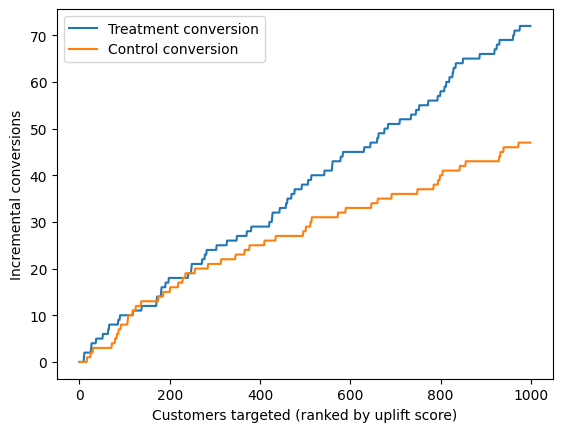

In [64]:
plt.plot(cum_outcome_treat, label="Treatment conversion")
plt.plot(cum_outcome_control, label="Control conversion")
plt.xlabel("Customers targeted (ranked by uplift score)")
plt.ylabel("Incremental conversions")
plt.legend()

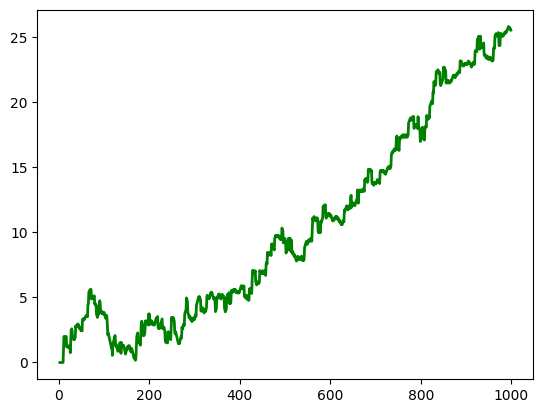

In [50]:
plt.plot(incremental_gain, label="Incremental gain (Qini curve)", linewidth=2, color="green")


In [77]:
incremental_gain.head(70)

0          NaN
1          NaN
2     0.000000
3     0.000000
4     0.000000
        ...   
65    4.500000
66    5.416667
67    5.486486
68    5.552632
69    5.615385
Length: 70, dtype: float64

In [78]:
import pandas as pd
import numpy as np
from pathlib import Path

rng = np.random.default_rng(42)

# -----------------------------
# Configuration
# -----------------------------
dates = pd.date_range("2025-08-01", "2026-07-31", freq="D")

campaigns = pd.DataFrame([
    ["C001", "Summer Collection Launch", "Paid Social", "Meta", "Prospecting", "New Collection", 4200, 0.42],
    ["C002", "Denim Performance", "Paid Search", "Google", "High Intent", "Performance", 3600, 0.35],
    ["C003", "New Customer Acquisition", "Paid Social", "Instagram", "Prospecting", "Acquisition", 5000, 0.38],
    ["C004", "Retargeting 7D", "Paid Social", "Meta", "Retargeting", "Conversion", 2200, 0.55],
    ["C005", "Retargeting 30D", "Paid Social", "Meta", "Retargeting", "Conversion", 1800, 0.50],
    ["C006", "Creator / Influencer", "Video", "YouTube", "Prospecting", "Awareness", 3000, 0.28],
    ["C007", "Festive Collection", "Paid Social", "Meta", "Prospecting", "Seasonal", 6000, 0.45],
    ["C008", "Clearance / Markdown", "Paid Search", "Google", "High Intent", "Promotion", 4000, 0.30],
    ["C009", "Premium Collection", "Paid Social", "Instagram", "Prospecting", "Premium", 3200, 0.33],
    ["C010", "Cart Abandonment", "CRM", "Email", "Retention", "Conversion", 900, 0.62],
    ["C011", "Brand Awareness", "Video", "YouTube", "Broad", "Awareness", 2500, 0.22],
    ["C012", "Flash Sale", "Paid Social", "Meta", "Broad", "Promotion", 7000, 0.40],
], columns=["campaign_id","campaign_name","channel","platform","audience_type","campaign_type","base_budget","response_strength"])

products = pd.DataFrame([
    ["SKU001","Women's Dresses","Midi Dress",79,0.55],
    ["SKU002","Women's Dresses","Maxi Dress",99,0.57],
    ["SKU003","Tops","Basic Tee",29,0.48],
    ["SKU004","Tops","Premium Blouse",59,0.52],
    ["SKU005","Bottoms","Straight Jeans",89,0.50],
    ["SKU006","Bottoms","Wide Leg Jeans",95,0.51],
    ["SKU007","Outerwear","Oversized Jacket",129,0.58],
    ["SKU008","Outerwear","Lightweight Blazer",149,0.60],
    ["SKU009","Activewear","Leggings",49,0.47],
    ["SKU010","Activewear","Performance Set",89,0.53],
    ["SKU011","Accessories","Handbag",119,0.62],
    ["SKU012","Accessories","Sneakers",109,0.54],
    ["SKU013","Men's Shirts","Oxford Shirt",69,0.51],
    ["SKU014","Men's Shirts","Overshirt",79,0.53],
    ["SKU015","Men's Bottoms","Chino",75,0.50],
    ["SKU016","Men's Bottoms","Cargo Pants",85,0.52],
    ["SKU017","Knitwear","Crewneck Sweater",89,0.56],
    ["SKU018","Knitwear","Cardigan",99,0.57],
    ["SKU019","Occasionwear","Party Dress",139,0.61],
    ["SKU020","Occasionwear","Tailored Suit",199,0.63],
], columns=["sku","category","subcategory","price","gross_margin_rate"])

# Product x campaign x day panel: 87,600 rows
rows = []
campaign_effect = dict(zip(campaigns.campaign_id, campaigns.response_strength))
campaign_base = dict(zip(campaigns.campaign_id, campaigns.base_budget))

for d in dates:
    dow = d.dayofweek
    month = d.month
    
    # Seasonal demand pattern
    seasonality = (
        1.00
        + 0.08 * np.sin((d.dayofyear / 365.25) * 2 * np.pi)
        + (0.22 if month in [10, 11, 12] else 0)
        + (0.10 if month in [3, 4] else 0)
    )
    weekend = 1.08 if dow >= 5 else 1.0
    
    # Commercial events
    black_friday = 1.0 if pd.Timestamp("2025-11-24") <= d <= pd.Timestamp("2025-12-01") else 0.0
    festive = 1.0 if pd.Timestamp("2025-10-15") <= d <= pd.Timestamp("2025-11-15") else 0.0
    summer_sale = 1.0 if pd.Timestamp("2026-05-20") <= d <= pd.Timestamp("2026-06-15") else 0.0
    
    for _, c in campaigns.iterrows():
        # Budget pacing + campaign-specific volatility
        budget = c.base_budget * (0.85 + 0.30 * rng.random())
        if c.campaign_id == "C007":
            budget *= 1 + 0.8 * festive
        if c.campaign_id == "C012":
            budget *= 1 + 1.2 * black_friday
        if c.campaign_id == "C008":
            budget *= 1 + 0.7 * summer_sale
        
        spend = budget * (0.88 + 0.18 * rng.random())
        impressions = max(100, spend / rng.uniform(5.5, 11.5) * 1000)
        
        # Campaign-specific CTR
        ctr_base = {
            "C001": .010, "C002": .026, "C003": .008,
            "C004": .032, "C005": .020, "C006": .006,
            "C007": .012, "C008": .030, "C009": .009,
            "C010": .055, "C011": .004, "C012": .014
        }[c.campaign_id]
        ctr = np.clip(ctr_base * (1 + rng.normal(0, .12)), .0015, .09)
        clicks = max(1, int(impressions * ctr))
        cpc = spend / clicks
        
        # Product distribution
        for _, p in products.iterrows():
            # Category demand + price effects
            category_factor = {
                "Women's Dresses": 1.15, "Tops": 1.25, "Bottoms": 1.00,
                "Outerwear": .70, "Activewear": .90, "Accessories": .82,
                "Men's Shirts": .90, "Men's Bottoms": .85, "Knitwear": .65,
                "Occasionwear": .75
            }[p.category]
            
            promo = 0.0
            if c.campaign_type == "Promotion":
                promo = .20
            elif black_friday:
                promo = .25
            elif summer_sale:
                promo = .15
            
            discount_pct = np.clip(promo + rng.normal(0, .025), 0, .40)
            
            # Inventory pressure; stock can constrain observed sales
            opening_stock = int(max(10, rng.normal(550 * category_factor, 100)))
            demand_multiplier = (
                seasonality * weekend * category_factor
                * (1 + 0.7 * festive * (p.category in ["Women's Dresses","Occasionwear"]))
                * (1 + 0.5 * black_friday)
                * (1 + 0.35 * summer_sale)
                * (1 + discount_pct)
            )
            
            # Campaign response: nonlinear diminishing returns
            saturation = np.log1p(spend / 1000)
            response = (1 + c.response_strength * saturation * 0.55)
            
            base_orders = clicks * 0.018 * demand_multiplier * response * (1 + rng.normal(0, .08))
            orders = max(0, int(np.round(base_orders * (1 - 0.03 * (p.price > 150)))))
            units_sold = min(orders, opening_stock)
            
            stockout_flag = int(units_sold >= opening_stock * .98)
            returns = int(np.round(units_sold * np.clip(
                0.08 + 0.05 * (p.category in ["Women's Dresses","Occasionwear"]) + rng.normal(0,.015),
                0.03, 0.30
            )))
            
            gross_revenue = units_sold * p.price
            discount_amount = gross_revenue * discount_pct
            net_revenue = max(0, gross_revenue - discount_amount)
            cogs = net_revenue * (1 - p.gross_margin_rate)
            contribution_margin = net_revenue - cogs - spend / len(products)
            
            rows.append([
                d, c.campaign_id, c.campaign_name, c.channel, c.platform,
                c.audience_type, c.campaign_type, p.sku, p.category, p.subcategory,
                p.price, opening_stock, spend / len(products), impressions / len(products),
                clicks / len(products), ctr, cpc, units_sold, returns, discount_pct,
                gross_revenue, discount_amount, net_revenue, cogs, contribution_margin,
                stockout_flag
            ])

cols = [
    "date","campaign_id","campaign_name","channel","platform","audience_type","campaign_type",
    "sku","category","subcategory","price","opening_stock","spend","impressions","clicks",
    "ctr","cpc","units_sold","returns","discount_pct","gross_revenue","discount_amount",
    "net_revenue","cogs","contribution_margin","stockout_flag"
]
df = pd.DataFrame(rows, columns=cols)

# Aggregate campaign/day level for the response model
camp = (
    df.groupby(["date","campaign_id","campaign_name","channel","platform","audience_type","campaign_type"], as_index=False)
      .agg({
          "spend":"sum","impressions":"sum","clicks":"sum","units_sold":"sum","returns":"sum",
          "gross_revenue":"sum","discount_amount":"sum","net_revenue":"sum","cogs":"sum",
          "contribution_margin":"sum","stockout_flag":"max"
      })
)

camp["ctr"] = camp["clicks"] / camp["impressions"]
camp["cpc"] = camp["spend"] / camp["clicks"].clip(lower=1)
camp["orders"] = np.maximum(0, np.round(camp["units_sold"] * .93)).astype(int)
camp["conversion_rate"] = camp["orders"] / camp["clicks"].clip(lower=1)
camp["aov"] = camp["net_revenue"] / camp["orders"].clip(lower=1)
camp["cpa"] = camp["spend"] / camp["orders"].clip(lower=1)
camp["roas"] = camp["net_revenue"] / camp["spend"].clip(lower=.01)
camp["profit_roas"] = camp["contribution_margin"] / camp["spend"].clip(lower=.01)
camp["new_customers"] = np.maximum(0, np.round(camp["orders"] * (
    .30 + .25 * (camp["audience_type"].eq("Prospecting")) + rng.normal(0,.04,len(camp))
))).astype(int)
camp["return_rate"] = camp["returns"] / camp["units_sold"].clip(lower=1)

# Add response-model features
camp = camp.sort_values(["campaign_id","date"]).reset_index(drop=True)
for lag in [1, 3, 7, 14]:
    camp[f"spend_lag_{lag}d"] = camp.groupby("campaign_id")["spend"].shift(lag).fillna(0)

# Adstock / carryover
def adstock(x, decay):
    out = np.zeros(len(x))
    for i, val in enumerate(x):
        out[i] = val + (decay * out[i-1] if i else 0)
    return out

camp["adstock_7d"] = camp.groupby("campaign_id")["spend"].transform(lambda x: adstock(x.to_numpy(), .80))
camp["adstock_14d"] = camp.groupby("campaign_id")["spend"].transform(lambda x: adstock(x.to_numpy(), .90))

camp["creative_fatigue"] = (
    camp.groupby("campaign_id")["impressions"].transform(
        lambda x: x.rolling(7, min_periods=1).mean()
    ) / camp["impressions"].clip(lower=1)
)

camp["campaign_saturation"] = np.log1p(camp["spend"]) / np.log1p(
    camp.groupby("campaign_id")["spend"].transform("max")
)

camp["day_of_week"] = camp["date"].dt.day_name()
camp["month"] = camp["date"].dt.month
camp["week"] = camp["date"].dt.isocalendar().week.astype(int)
camp["quarter"] = camp["date"].dt.quarter
camp["holiday_flag"] = (
    ((camp["date"].dt.month == 11) & (camp["date"].dt.day >= 24)) |
    ((camp["date"].dt.month == 12) & (camp["date"].dt.day <= 2))
).astype(int)

camp["incremental_revenue_proxy"] = (
    camp["net_revenue"] * (
        0.35
        + 0.35 * np.tanh(camp["adstock_7d"] / camp["spend"].clip(lower=1))
        + 0.10 * (1 - camp["campaign_saturation"])
    )
).clip(lower=0)

camp["marginal_roas_proxy"] = (
    camp["incremental_revenue_proxy"] / camp["spend"].clip(lower=.01)
)

# Round sensible numeric fields
for col in ["spend","gross_revenue","discount_amount","net_revenue","cogs","contribution_margin",
            "aov","cpa","roas","profit_roas","adstock_7d","adstock_14d",
            "incremental_revenue_proxy","marginal_roas_proxy"]:
    camp[col] = camp[col].round(2)

df["date"] = pd.to_datetime(df["date"])

# Save files
out = Path("/mnt/data")
daily_file = out / "fashion_retail_campaign_product_daily.csv"
response_file = out / "fashion_retail_campaign_response_model.csv"
xlsx_file = out / "fashion_retail_response_model.xlsx"

df.to_csv(daily_file, index=False)
camp.to_csv(response_file, index=False)

with pd.ExcelWriter(xlsx_file, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Product_Daily", index=False)
    camp.to_excel(writer, sheet_name="Response_Model", index=False)
    campaigns.to_excel(writer, sheet_name="Campaign_Master", index=False)
    products.to_excel(writer, sheet_name="Product_Master", index=False)

print(f"Created {len(df):,} product/campaign/day rows.")
print(f"Created {len(camp):,} campaign/day response-model rows.")
print(daily_file)
print(response_file)
print(xlsx_file)


OSError: Cannot save file into a non-existent directory: '\mnt\data'